In [ ]:
!pip install Keras
!pip install vit-keras
!pip install tensorflow-addons

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.0/40.0 kB 4.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 611.8/611.8 kB 11.2 MB/s eta 0:00:00


In [ ]:
from vit_keras import vit, utils

/usr/local/lib/python3.10/dist-packages/tensorflow_addons/utils/tfa_eol_msg.py:23: UserWarning: 

TensorFlow Addons (TFA) has ended development and introduction of new features.
TFA has entered a minimal maintenance and release mode until a planned end of life in May 2024.
Please modify downstream libraries to take dependencies from other repositories in our TensorFlow community (e.g. Keras, Keras-CV, and Keras-NLP). 

For more information see: https://github.com/tensorflow/addons/issues/2807 

  warnings.warn(


In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Flatten, Dense
from tensorflow.keras.applications import VGG19
from tensorflow.keras.models import Model

In [ ]:

import os

import keras.preprocessing
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras

from keras.preprocessing import image
from keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
from keras import layers
from keras import regularizers, activations
from keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from keras.callbacks import ModelCheckpoint
from keras.layers import Dense, Dropout, Flatten, Activation, Concatenate, Lambda
from keras.layers import Input, Conv2D, MaxPooling2D, GlobalAveragePooling2D, BatchNormalization, ZeroPadding2D
from keras.models import Model
from keras.optimizers import Adam
from keras.applications import ResNet50V2
from keras.preprocessing.image import ImageDataGenerator
from vit_keras import vit, utils

In [ ]:
import warnings
warnings.filterwarnings("ignore")

In [ ]:
# prompt: Load google drive

from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
# prompt: !unzip "/content/drive/MyDrive/Data for Ovarian Cancer.zip" and store in /content/data

!unzip "/content/drive/MyDrive/Data for Ovarian Cancer.zip" -d /content/data


Archive:  /content/drive/MyDrive/Data for Ovarian Cancer.zip
   creating: /content/data/Clear_Cell/
  inflating: /content/data/Clear_Cell/C68.JPG  
  inflating: /content/data/Clear_Cell/image_cc_0_7938.jpg  
  inflating: /content/data/Clear_Cell/C59.JPG  
  inflating: /content/data/Clear_Cell/C76JPG.JPG  
  inflating: /content/data/Clear_Cell/C77.JPG  
  inflating: /content/data/Clear_Cell/image_cc_0_9901.jpg  
  inflating: /content/data/Clear_Cell/c14JPG.JPG  
  inflating: /content/data/Clear_Cell/clear2.JPG  
  inflating: /content/data/Clear_Cell/c33.JPG  
  inflating: /content/data/Clear_Cell/C51.JPG  
  inflating: /content/data/Clear_Cell/c15.JPG  
  inflating: /content/data/Clear_Cell/C60.JPG  
  inflating: /content/data/Clear_Cell/image_cc_0_199.jpg  
  inflating: /content/data/Clear_Cell/C42.JPG  
  inflating: /content/data/Clear_Cell/c24.JPG  
  inflating: /content/data/Clear_Cell/c6.JPG  
  inflating: /content/data/Clear_Cell/image_cc_0_3624.jpg  
  inflating: /content/data/Cl

In [ ]:
base_dir = '/content/data'

In [ ]:
import os

directory_path = base_dir
class_folders =[]
# Check if the directory exists
if os.path.exists(directory_path) and os.path.isdir(directory_path):
    # Get all folder names in the specified directory
    folder_names = [folder for folder in os.listdir(directory_path) if os.path.isdir(os.path.join(directory_path, folder))]

    # Print the folder names
    print("Folder names in '{}':".format(directory_path))
    for folder_name in folder_names:
        class_folders.append(folder_name)
        print(folder_name)
else:
    print("The specified directory does not exist.")


Folder names in '/content/data':
Mucinous
Non_Cancerous
Endometri
Serous
Clear_Cell


In [ ]:
import os
from collections import defaultdict

def count_images_in_folders(root_folder):
    image_count_per_folder = defaultdict(int)

    for folder_name in os.listdir(root_folder):
        folder_path = os.path.join(root_folder, folder_name)

        if os.path.isdir(folder_path):
            image_count = sum(1 for file in os.listdir(folder_path) if file.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp')))
            image_count_per_folder[folder_name] = image_count

    return image_count_per_folder

# Specify the root folder where your image folders are located
root_folder_path = base_dir

image_counts = count_images_in_folders(root_folder_path)

# Print the results
for folder_name, count in image_counts.items():
    print(f"{folder_name}: {count} images")


Mucinous: 100 images
Non_Cancerous: 100 images
Endometri: 98 images
Serous: 100 images
Clear_Cell: 100 images


In [ ]:
from PIL import Image
import os

def resize_images_in_folder(input_folder, output_folder, target_size=(224, 224)):
    # Create the output folder if it doesn't exist
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)

    # Loop through all files in the input folder
    for filename in os.listdir(input_folder):
        # Check if the file is an image
        if filename.lower().endswith(('.png', '.jpg', '.jpeg', '.gif')):
            # Open the image file
            with Image.open(os.path.join(input_folder, filename)) as img:
                # Resize the image
                resized_img = img.resize(target_size)
                # Save the resized image to the output folder
                resized_img.save(os.path.join(output_folder, filename), format='PNG')

def resize_images_in_main_folder(main_folder, output_main_folder, target_size=(224, 224)):
    # Iterate through all subfolders in the main folder
    for subfolder in os.listdir(main_folder):
        input_folder = os.path.join(main_folder, subfolder)
        output_folder = os.path.join(output_main_folder, subfolder)
        # Resize images in each subfolder
        resize_images_in_folder(input_folder, output_folder, target_size)

# Specify the main folder containing subfolders
main_folder = '/content/data'
output_main_folder = '/content/resized'

# Call the function to resize images in each subfolder
resize_images_in_main_folder(main_folder, output_main_folder)


In [ ]:
import os
import cv2
from tqdm import tqdm

def invert_colors(image):
    inverted_image = cv2.bitwise_not(image)
    return inverted_image

def invert_colors_in_subfolders(root_directory, output_directory):
    # Iterate through subfolders
    for subfolder in os.listdir(root_directory):
        subfolder_path = os.path.join(root_directory, subfolder)

        # Check if it's a directory
        if os.path.isdir(subfolder_path):
            # Define source and output directories for the current subfolder
            source_directory = subfolder_path
            output_subfolder = os.path.join(output_directory, subfolder)

            # Create output directory if it doesn't exist
            if not os.path.exists(output_subfolder):
                os.makedirs(output_subfolder)

            # Process images in the current subfolder
            image_files = [f for f in os.listdir(source_directory) if f.endswith(('.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff'))]
            for file_name in tqdm(image_files, desc="Processing " + subfolder):
                # Construct the input and output paths
                input_image_path = os.path.join(source_directory, file_name)
                output_image_path = os.path.join(output_subfolder, file_name)

                # Read the image
                image = cv2.imread(input_image_path)

                # Check if the image is loaded successfully
                if image is not None:
                    # Perform color inversion
                    inverted_image = invert_colors(image)

                    # Save the inverted image
                    cv2.imwrite(output_image_path, inverted_image)
                else:
                    print("Error: Could not open or find the image:", input_image_path)

# Example usage
root_directory = '/content/resized'
output_directory = '/content/invert'  # Provide the path to your output directory
invert_colors_in_subfolders(root_directory, output_directory)

Processing Clear_Cell: 100%|██████████| 26/26 [00:00<00:00, 296.09it/s]


In [ ]:
import os
from tqdm import tqdm
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image

def augment_images(source_directory, output_directory, target_count=2000):
    # Create an ImageDataGenerator
    datagen = ImageDataGenerator(
    featurewise_center=True,
    samplewise_center=True,
    featurewise_std_normalization=True,
    samplewise_std_normalization=True,
    zca_whitening=True,
    zca_epsilon=1e-10,
    rotation_range=30,
    width_shift_range=0.3,
    height_shift_range=0.3,
    brightness_range=[0.5, 1.5],
    shear_range=0.3,
    zoom_range=0.3,
    channel_shift_range=0.3,
    cval=0.3,
    horizontal_flip=True,
    vertical_flip=True,
    interpolation_order=2)

    # Ensure the destination directory exists; create it if necessary
    if not os.path.exists(output_directory):
        os.makedirs(output_directory)

    # Get the list of files in the source directory
    image_files = [f for f in os.listdir(source_directory) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

    # Calculate the number of additional images needed
    existing_images = len(image_files)
    images_per_original = max(1, target_count // existing_images)

    # Augment images until the target count is reached
    for filename in tqdm(image_files, desc="Augmenting images"):
        img_path = os.path.join(source_directory, filename)
        img = image.load_img(img_path)
        img_array = image.img_to_array(img)
        img_array = img_array.reshape((1,) + img_array.shape)

        # Generate augmented images
        i = 0
        for batch in datagen.flow(img_array, batch_size=1, save_to_dir=output_directory, save_prefix='aug', save_format='jpg'):
            i += 1
            if i >= images_per_original:
                break

    # Remove excess images from the output directory
    output_images = os.listdir(output_directory)
    for i in range(len(output_images) - target_count):
        os.remove(os.path.join(output_directory, output_images[i]))

    print(f"Augmentation complete. Total images in '{output_directory}': {len(os.listdir(output_directory))}")

import os

# Specify the root directory containing subfolders
root_directory = '/content/invert'

# Iterate through subfolders
for subfolder in os.listdir(root_directory):
    subfolder_path = os.path.join(root_directory, subfolder)

    # Check if it's a directory
    if os.path.isdir(subfolder_path):
        # Define source and output directories for the current subfolder
        source_directory = subfolder_path
        output_directory = os.path.join('/content/augmented_invert1', subfolder)

        # Call the augment_images function for the current subfolder
        augment_images(source_directory, output_directory, target_count=2000)


Augmenting images: 100%|██████████| 21/21 [00:55<00:00,  2.64s/it]


Augmentation complete. Total images in '/content/augmented_invert1/Mucinous': 1819


Augmenting images: 100%|██████████| 37/37 [00:47<00:00,  1.29s/it]


Augmentation complete. Total images in '/content/augmented_invert1/Non_Cancerous': 1811


Augmenting images: 100%|██████████| 84/84 [00:47<00:00,  1.78it/s]


Augmentation complete. Total images in '/content/augmented_invert1/Endometri': 1726


Augmenting images: 100%|██████████| 64/64 [00:48<00:00,  1.31it/s]


Augmentation complete. Total images in '/content/augmented_invert1/Serous': 1825


Augmenting images: 100%|██████████| 26/26 [00:46<00:00,  1.79s/it]

Augmentation complete. Total images in '/content/augmented_invert1/Clear_Cell': 1804


In [ ]:
base_dir = '/content/augmented_invert1'

In [ ]:
import os
from collections import defaultdict

def count_images_in_folders(root_folder):
    image_count_per_folder = defaultdict(int)

    for folder_name in os.listdir(root_folder):
        folder_path = os.path.join(root_folder, folder_name)

        if os.path.isdir(folder_path):
            image_count = sum(1 for file in os.listdir(folder_path) if file.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp')))
            image_count_per_folder[folder_name] = image_count

    return image_count_per_folder

# Specify the root folder where your image folders are located
root_folder_path = base_dir

image_counts = count_images_in_folders(root_folder_path)

# Print the results
for folder_name, count in image_counts.items():
    print(f"{folder_name}: {count} images")


Mucinous: 1819 images
Non_Cancerous: 1811 images
Endometri: 1726 images
Serous: 1825 images
Clear_Cell: 1804 images


In [ ]:
import cv2
import os

# Create the output folder if it doesn't exist
output_folder = '/content/pp'
if not os.path.exists(output_folder):
    os.makedirs(output_folder)

# Iterate through all subfolders in the main folder
for subfolder in os.listdir('/content/augmented_invert'):
    input_folder = os.path.join('/content/augmented_invert', subfolder)
    # Create subfolder in the destination directory if it doesn't exist
    output_subfolder = os.path.join(output_folder, subfolder)
    if not os.path.exists(output_subfolder):
        os.makedirs(output_subfolder)
    # Iterate through all images in the subfolder
    for filename in os.listdir(input_folder):
        if filename.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp')):
            # Open the image file
            img = cv2.imread(os.path.join(input_folder, filename), cv2.IMREAD_GRAYSCALE)
            # Apply Histogram Equalization
            equ = cv2.equalizeHist(img)
            # Save the equalized image to the output subfolder
            cv2.imwrite(os.path.join(output_subfolder, filename), equ)


In [ ]:
base_dir = "/content/augmented_invert1"

In [ ]:
import os
import cv2
import numpy as np

# Function to detect outliers using Modified Z-score method with Median Absolute Deviation (MAD)
def detect_outliers_mad(data, threshold=3.5):
    median = np.median(data)
    mad = np.median(np.abs(data - median))
    modified_z_scores = 0.6745 * (data - median) / mad
    outliers = np.abs(modified_z_scores) > threshold
    return outliers

# Function to handle outliers in an image using Modified Z-score with MAD
def handle_outliers(image):
    # Flatten the image into a 1D array
    flattened_image = image.flatten()
    # Detect outliers using Modified Z-score with MAD
    outliers = detect_outliers_mad(flattened_image)
    # Replace outliers with median value
    median_value = np.median(flattened_image)
    cleaned_image = np.where(outliers, median_value, flattened_image)
    # Reshape the flattened image back to its original shape
    cleaned_image = cleaned_image.reshape(image.shape)
    return cleaned_image

# Root directory
root_dir = base_dir

# Iterate through each subfolder
for subdir in os.listdir(root_dir):
    subdir_path = os.path.join(root_dir, subdir)
    if os.path.isdir(subdir_path):
        print("Processing subfolder:", subdir)
        # Iterate through each file in the subfolder
        for file_name in os.listdir(subdir_path):
            file_path = os.path.join(subdir_path, file_name)
            if file_name.lower().endswith(('.jpg', '.jpeg', '.png')):
                print("Processing file:", file_name)
                # Load the image
                image = cv2.imread(file_path)
                # Handling outliers using Modified Z-score with MAD
                cleaned_image = handle_outliers(image)
                # Save the cleaned image
                cleaned_file_path = os.path.join(subdir_path, file_name)
                cv2.imwrite(cleaned_file_path, cleaned_image)
                print("Cleaned image saved at:", cleaned_file_path)


Streaming output truncated to the last 5000 lines.
Cleaned image saved at: /content/augmented_invert1/Serous/aug_0_5764.jpg
Processing file: aug_0_5904.jpg
Cleaned image saved at: /content/augmented_invert1/Serous/aug_0_5904.jpg
Processing file: aug_0_4490.jpg
Cleaned image saved at: /content/augmented_invert1/Serous/aug_0_4490.jpg
Processing file: aug_0_1036.jpg
Cleaned image saved at: /content/augmented_invert1/Serous/aug_0_1036.jpg
Processing file: aug_0_5621.jpg
Cleaned image saved at: /content/augmented_invert1/Serous/aug_0_5621.jpg
Processing file: aug_0_8956.jpg
Cleaned image saved at: /content/augmented_invert1/Serous/aug_0_8956.jpg
Processing file: aug_0_4412.jpg
Cleaned image saved at: /content/augmented_invert1/Serous/aug_0_4412.jpg
Processing file: aug_0_1541.jpg
Cleaned image saved at: /content/augmented_invert1/Serous/aug_0_1541.jpg
Processing file: aug_0_7850.jpg
Cleaned image saved at: /content/augmented_invert1/Serous/aug_0_7850.jpg
Processing file: aug_0_7243.jpg
Clea

In [ ]:
import os

def get_folder_names(directory_path):
    # Initialize an empty list to store folder names
    folder_names = []

    # Iterate over items in the specified directory
    for item in os.listdir(directory_path):
        item_path = os.path.join(directory_path, item)

        # Check if the item is a directory
        if os.path.isdir(item_path):
          if item != '.ipynb_checkpoints':
            folder_names.append(item)

    return folder_names

# Specify the directory path for which you want to fetch folder names
directory_path = "/content/augmented_invert1"

# Call the function to get folder names in the specified directory
folders = get_folder_names(directory_path)

# Print the list of folder names
print("Folder Names:", folders)

Folder Names: ['Mucinous', 'Non_Cancerous', 'Endometri', 'Serous', 'Clear_Cell']


In [ ]:
base_dir="/content/augmented_invert1"

In [ ]:
train_dir = os.path.join(base_dir, 'train')
os.makedirs(train_dir, exist_ok=True)

val_dir = os.path.join(base_dir, 'val')
os.makedirs(val_dir, exist_ok=True)

test_dir = os.path.join(base_dir, 'test')
os.makedirs(test_dir, exist_ok=True)

In [ ]:
import shutil

# List of class folder names
class_folders = folders
# Split ratios (adjust these as needed)
train_ratio = 0.7
val_ratio = 0.15
test_ratio = 0.15

for folder in class_folders:
    source_folder = os.path.join(base_dir, folder)
    train_dest = os.path.join(train_dir, folder)
    val_dest = os.path.join(val_dir, folder)
    test_dest = os.path.join(test_dir, folder)

    os.makedirs(train_dest, exist_ok=True)
    os.makedirs(val_dest, exist_ok=True)
    os.makedirs(test_dest, exist_ok=True)

    filenames = os.listdir(source_folder)
    num_files = len(filenames)

    num_train = int(num_files * train_ratio)
    num_val = int(num_files * val_ratio)

    train_files = filenames[:num_train]
    val_files = filenames[num_train:num_train + num_val]
    test_files = filenames[num_train + num_val:]

    for file in train_files:
        src_path = os.path.join(source_folder, file)
        dest_path = os.path.join(train_dest, file)
        shutil.copy(src_path, dest_path)

    for file in val_files:
        src_path = os.path.join(source_folder, file)
        dest_path = os.path.join(val_dest, file)
        shutil.copy(src_path, dest_path)

    for file in test_files:
        src_path = os.path.join(source_folder, file)
        dest_path = os.path.join(test_dest, file)
        shutil.copy(src_path, dest_path)

In [ ]:
size = 224

batch_size = 64
target_size = (size,size)  # Adjust as needed

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest')

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=target_size,
    class_mode='categorical',
    batch_size=batch_size)

val_datagen = ImageDataGenerator(rescale=1./255)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=target_size,
    class_mode='categorical',
    batch_size=batch_size,
    shuffle=False)

test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=target_size,
    class_mode='categorical',
    batch_size=batch_size,
    shuffle=False)

Found 6651 images belonging to 6 classes.
Found 1344 images belonging to 6 classes.
Found 1354 images belonging to 6 classes.


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.applications import VGG19, DenseNet201,ResNet50V2,Xception,ResNet101V2,EfficientNetV2S,MobileNetV2,InceptionV3
from tensorflow.keras.applications.vgg16 import preprocess_input

def create_vgg16_densenet_model(input_shape, num_classes):
    vgg16_backbone = MobileNetV2	(
        input_shape=input_shape,
        include_top=False,
        weights='imagenet',
        pooling='avg'  # We'll handle pooling ourselves
    )

    densenet_backbone = InceptionV3(
        input_shape=input_shape,
        include_top=False,
        weights='imagenet',
        classes=num_classes,
    )

    densenet_backbone.trainable = False
    vgg16_backbone.trainable = False

    input_layer = layers.Input(shape=input_shape)

    # VGG16 Backbone
    vgg16_features = vgg16_backbone(preprocess_input(input_layer))

    # DenseNet121 Backbone
    densenet_features = densenet_backbone(input_layer)
    densenet_features = GlobalAveragePooling2D()(densenet_features)

    # Concatenate Features
    combined_features = layers.Concatenate()([densenet_features, vgg16_features])
    x = layers.Flatten()(combined_features)
    x = layers.BatchNormalization()(x)
    # Dense layer with Batch Normalization
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    # x = layers.Dense(32, activation='relu')(x)
    # x = layers.Dense(32, activation='relu')(x)
    # x = layers.Dense(32, activation='relu')(x)
    # x = layers.Dense(32, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dense(128, activation='relu')(x)

    output_layer = layers.Dense(num_classes, activation='softmax')(x)

    model = tf.keras.models.Model(inputs=input_layer, outputs=output_layer)

    return model


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.layers import GlobalAveragePooling2D
from vit_keras import vit
from tensorflow.keras.applications import EfficientNetV2B3,DenseNet121

def create_vit_mobilenet_model(input_shape, num_classes):
    vit_backbone = vit.vit_b16(
        image_size=input_shape[:2],
        include_top=False,
        pretrained=True,
        pretrained_top=False,
        classes=num_classes,
        weights="imagenet21k",
    )

    mobilenet_backbone = InceptionV3(
        input_shape=input_shape,
        include_top=False,
        weights='imagenet',
        classes=num_classes,
    )

    mobilenet_backbone.trainable = False
    vit_backbone.trainable = False

    input_layer = layers.Input(shape=input_shape)

    # ViT Backbone
    vit_features = vit_backbone(input_layer)

    # MobileNetV2 Backbone
    mobilenet_features = mobilenet_backbone(input_layer)
    mobilenet_features = GlobalAveragePooling2D()(mobilenet_features)

    # Concatenate Features
    combined_features = layers.Concatenate()([vit_features, mobilenet_features])
    x = layers.Flatten()(combined_features)
    x = layers.BatchNormalization()(x)
    # Dense layer with Batch Normalization
    x = layers.Dense(32, activation='gelu')(x)
    x = layers.Dense(32, activation='gelu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(32, activation='gelu')(x)
    x = layers.Dense(32, activation='gelu')(x)

    output_layer = layers.Dense(5, activation='softmax')(x)

    model = tf.keras.models.Model(inputs=input_layer, outputs=output_layer)

    return model


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.layers import GlobalAveragePooling2D
from vit_keras import vit
from tensorflow.keras.applications import NASNetMobile

def create_vit_nasnet_model(input_shape, num_classes):
    vit_backbone = vit.vit_b16(
        image_size=input_shape[:2],
        include_top=False,
        pretrained=True,
        pretrained_top=False,
        classes=num_classes,
        weights="imagenet21k",
    )

    nasnet_backbone = NASNetMobile(
        input_shape=input_shape,
        include_top=False,
        weights='imagenet',
        classes=num_classes,
    )

    nasnet_backbone.trainable = False
    vit_backbone.trainable = False

    input_layer = layers.Input(shape=input_shape)

    # ViT Backbone
    vit_features = vit_backbone(input_layer)

    # NASNetMobile Backbone
    nasnet_features = nasnet_backbone(input_layer)
    nasnet_features = GlobalAveragePooling2D()(nasnet_features)

    # Concatenate Features
    combined_features = layers.Concatenate()([vit_features, nasnet_features])
    x = layers.Flatten()(combined_features)
    x = layers.BatchNormalization()(x)
    # Dense layer with Batch Normalization
    x = layers.Dense(512, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(256, activation='relu')(x)
    #x = layers.Dense(32, activation='relu')(x)

    output_layer = layers.Dense(num_classes, activation='softmax')(x)

    model = tf.keras.models.Model(inputs=input_layer, outputs=output_layer)

    return model

# Example usage
input_shape = (224, 224, 3)
num_classes = 5
model = create_vit_nasnet_model(input_shape, num_classes)
model.summary()


19993432/19993432 [==============================] - 2s 0us/step
Model: "model_9"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_30 (InputLayer)       [(None, 224, 224, 3)]        0         []                            
                                                                                                  
 NASNet (Functional)         (None, 7, 7, 1056)           4269716   ['input_30[0][0]']            
                                                                                                  
 vit-b16 (Functional)        (None, 768)                  8638924   ['input_30[0][0]']            
                                                          8                                       
                                                                                                  
 global_average_pooling2d_1

In [ ]:
input_shape = (size, size, 3) #input image shape
num_classes = 6  # Number of output classes


model = create_vit_nasnet_model(input_shape, num_classes)

optim = keras.optimizers.AdamW(
    learning_rate=0.001,
    weight_decay=0.004,
    beta_1=0.9,
    beta_2=0.999,
    epsilon=1e-07,
    amsgrad=True,
    clipnorm=None,
    clipvalue=None,
    global_clipnorm=None,
    use_ema=True,
    ema_momentum=0.99,
    ema_overwrite_frequency=None,
    name="adamw"
)

#custom_optimizer = Adam(learning_rate=0.01)

model.compile(
    optimizer=optim,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

#model.summary()


In [ ]:
# prompt: add early stopping and reduce lr also import libraries

from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Define the callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=5, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=3, min_lr=1e-15)


In [ ]:
progess = model.fit(
    train_generator,
    epochs=25,
    validation_data=val_generator,
    callbacks=[reduce_lr,early_stopping]
)

Epoch 1/25
104/104 [==============================] - 191s 2s/step - loss: 0.3609 - accuracy: 0.8659 - val_loss: 0.2506 - val_accuracy: 0.9152 - lr: 0.0010
Epoch 2/25
104/104 [==============================] - 150s 1s/step - loss: 0.1760 - accuracy: 0.9337 - val_loss: 0.1267 - val_accuracy: 0.9546 - lr: 0.0010
Epoch 3/25
104/104 [==============================] - 151s 1s/step - loss: 0.1253 - accuracy: 0.9510 - val_loss: 0.0983 - val_accuracy: 0.9598 - lr: 0.0010
Epoch 4/25
104/104 [==============================] - 149s 1s/step - loss: 0.1219 - accuracy: 0.9562 - val_loss: 0.1005 - val_accuracy: 0.9621 - lr: 0.0010
Epoch 5/25
104/104 [==============================] - 154s 1s/step - loss: 0.0989 - accuracy: 0.9645 - val_loss: 0.0693 - val_accuracy: 0.9732 - lr: 0.0010
Epoch 6/25
104/104 [==============================] - 153s 1s/step - loss: 0.1019 - accuracy: 0.9632 - val_loss: 0.0586 - val_accuracy: 0.9799 - lr: 0.0010
Epoch 7/25
104/104 [==============================] - 153s 1s/st

In [ ]:
test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

22/22 [==============================] - 20s 897ms/step - loss: 0.0301 - accuracy: 0.9919
Test Loss: 0.0301
Test Accuracy: 0.9919


In [ ]:
test_labels = np.array(test_generator.labels)

22/22 [==============================] - 27s 850ms/step


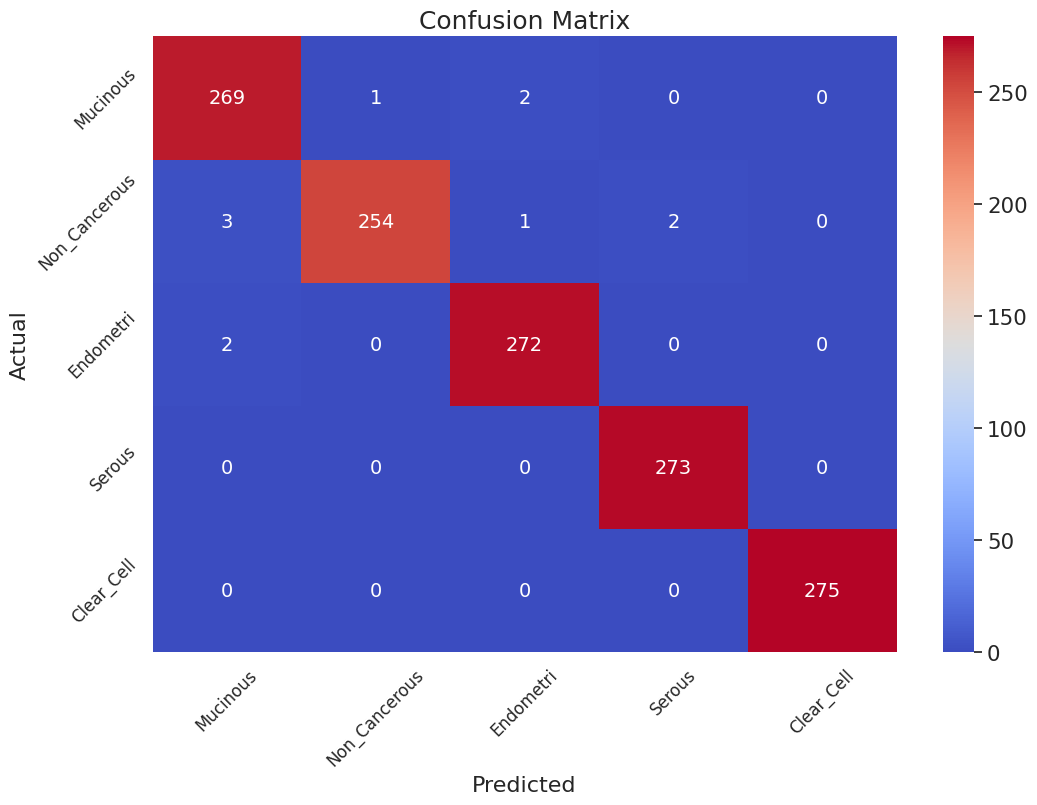

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Assuming you have already trained and compiled your model
# train_ds is your training dataset

# Make predictions using the trained model
predictions = model.predict(test_generator)

# Convert predicted probabilities to class labels
predicted_labels = np.argmax(predictions, axis=1)

# Get the actual labels from the dataset

# Calculate the confusion matrix
confusion_mtx = confusion_matrix(test_labels, predicted_labels)
classes = class_folders

import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

classes = class_folders

# Set the font scale for Seaborn
sns.set(font_scale=1.4)  # Adjust the font scale as needed

# Create a Seaborn heatmap for the confusion matrix
plt.figure(figsize=(12, 8))
sns.heatmap(confusion_mtx, annot=True, fmt='d', cmap='coolwarm',
            annot_kws={"size": 14},  # Adjust the annotation font size
            xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted', fontsize=16)  # Adjust the label font size
plt.ylabel('Actual', fontsize=16)  # Adjust the label font size
plt.title('Confusion Matrix', fontsize=18)  # Adjust the title font size
plt.xticks(rotation=45, fontsize=12)  # Adjust the x-tick font size and rotation
plt.yticks(rotation=45, fontsize=12)  # Adjust the y-tick font size and rotation
plt.show()


In [ ]:
# prompt: print the precision recall and f1 score

from sklearn.metrics import classification_report
# Get the classification report
report = classification_report(test_labels, predicted_labels)

# Print the report
print(report)


              precision    recall  f1-score   support

           0       0.98      0.99      0.99       272
           1       1.00      0.98      0.99       260
           2       0.99      0.99      0.99       274
           3       0.99      1.00      1.00       273
           4       1.00      1.00      1.00       275

    accuracy                           0.99      1354
   macro avg       0.99      0.99      0.99      1354
weighted avg       0.99      0.99      0.99      1354



In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Assuming test_labels and predicted_labels are your actual and predicted labels
precision = precision_score(test_labels, predicted_labels, average='macro')
recall = recall_score(test_labels, predicted_labels, average='macro')
f1 = f1_score(test_labels, predicted_labels, average='macro')

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)


Precision: 0.9919296876016499
Recall: 0.9917188790170757
F1 Score: 0.9917997298355836


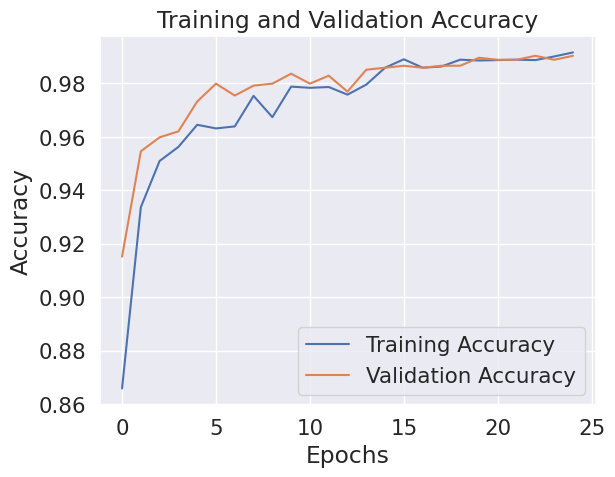

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming you have the progress object with accuracy and loss data
acc = progess.history['accuracy']
val_acc = progess.history['val_accuracy']
loss = progess.history['loss']
val_loss = progess.history['val_loss']

epochs = range(1, len(acc) + 1)  # Assuming each epoch's data is available

# Plotting

# Plot training and validation accuracy
sns.lineplot(acc, label='Training Accuracy')
sns.lineplot(val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot training and validation loss

plt.show()


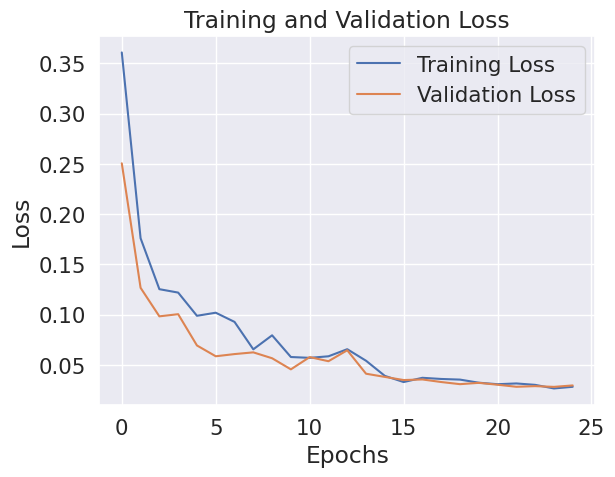

In [ ]:

sns.lineplot(loss, label='Training Loss')
sns.lineplot(val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()


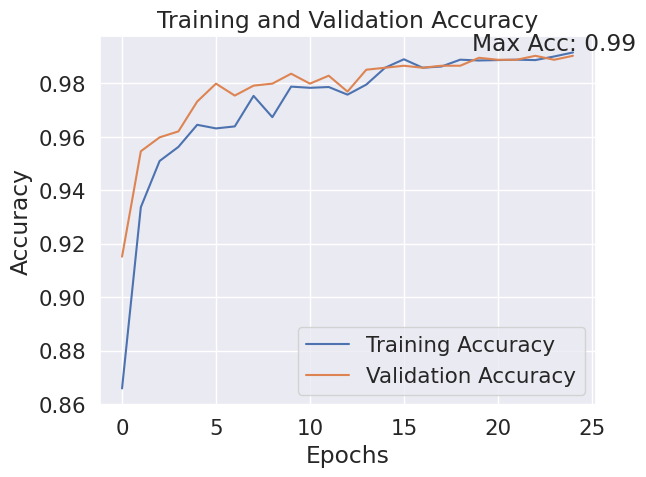

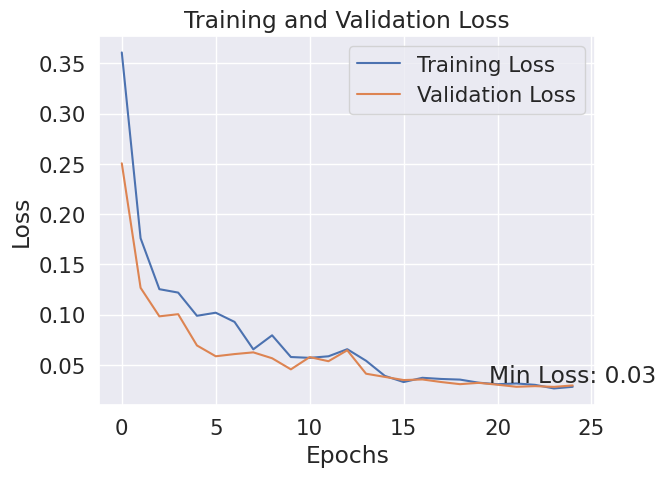

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming you have the progress object with accuracy and loss data
acc = progess.history['accuracy']
val_acc = progess.history['val_accuracy']
loss = progess.history['loss']
val_loss = progess.history['val_loss']

epochs = range(1, len(acc) + 1)  # Assuming each epoch's data is available

# Plotting

# Plot training and validation accuracy
sns.lineplot( acc, label='Training Accuracy')
sns.lineplot( val_acc, label='Validation Accuracy')

# Find and annotate peak accuracy
peak_acc_epoch = val_acc.index(max(val_acc)) + 1
peak_acc_value = max(val_acc)
plt.text(peak_acc_epoch, peak_acc_value, f'Max Acc: {peak_acc_value:.2f}', ha='center', va='bottom')

plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

# Plot training and validation loss

sns.lineplot( loss, label='Training Loss')
sns.lineplot( val_loss, label='Validation Loss')

# Find and annotate peak loss
peak_loss_epoch = val_loss.index(min(val_loss)) + 1
peak_loss_value = min(val_loss)
plt.text(peak_loss_epoch, peak_loss_value, f'Min Loss: {peak_loss_value:.2f}', ha='center', va='bottom')

plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()


22/22 [==============================] - 19s 837ms/step


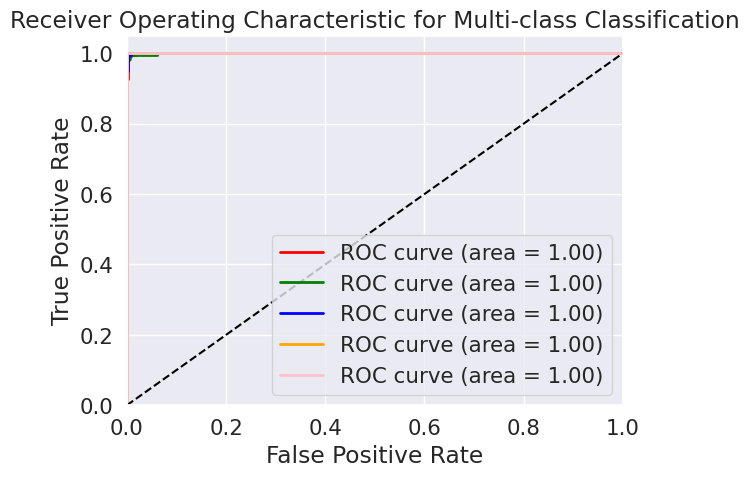

AUC scores:
Class 1: 0.9997349679243231
Class 2: 0.9996554633666149
Class 3: 0.999868207623682
Class 4: 1.0
Class 5: 1.0


In [ ]:
# prompt: ROC Curve display for deep learning

# Get predicted probabilities for each class
predictions = model.predict(test_generator)

# Get the actual labels
test_labels = np.array(test_generator.labels)

# Binarize the test labels
test_labels_bin = keras.utils.to_categorical(test_labels)

# Calculate ROC curves and AUC for each class
fpr = {}
tpr = {}
auc_scores = {}

n_classes = 5  # Adjust this to your number of classes

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(test_labels_bin[:, i], predictions[:, i])
    auc_scores[i] = auc(fpr[i], tpr[i])

# Plot the ROC curves
plt.figure()
lw = 2
colors = ['red', 'green', 'blue', 'orange','pink']  # Adjust colors for each class

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=lw,
             label='ROC curve (area = %0.2f)' % auc_scores[i])

plt.plot([0, 1], [0, 1], color='black', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic for Multi-class Classification')
plt.legend(loc="lower right")
plt.show()

# Print AUC scores
print('AUC scores:')
for i, score in auc_scores.items():
    print(f'Class {i+1}: {score}')


22/22 [==============================] - 21s 923ms/step


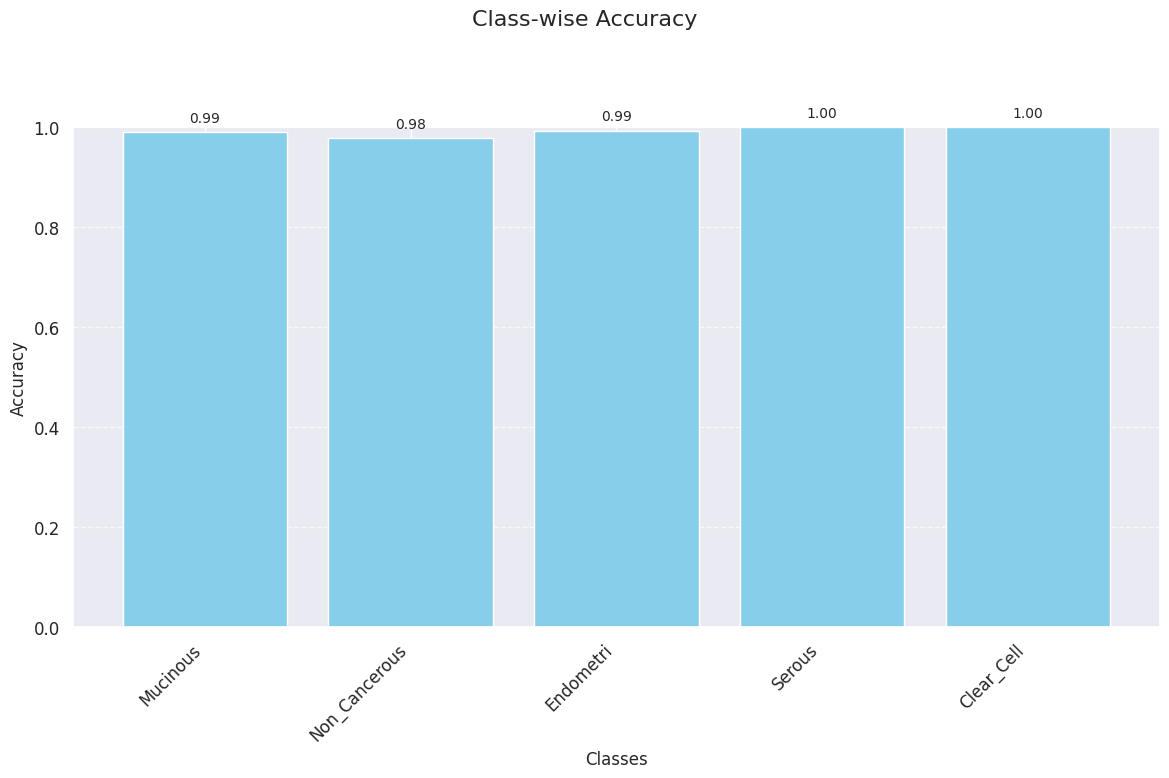

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Assuming you have already trained and compiled your model
# Make predictions using the trained model
predictions = model.predict(test_generator)

# Convert predicted probabilities to class labels
predicted_labels = np.argmax(predictions, axis=1)

# Get the actual labels from the dataset
# test_labels should be an array of the true labels
# class_folders should be a list of class names

# Calculate the confusion matrix
confusion_mtx = confusion_matrix(test_labels, predicted_labels)

# Calculate class-wise accuracy
class_wise_accuracy = confusion_mtx.diagonal() / confusion_mtx.sum(axis=1)

# Create a bar plot for class-wise accuracy
plt.figure(figsize=(12, 8))
plt.bar(range(len(class_wise_accuracy)), class_wise_accuracy, color='skyblue')
plt.xlabel('Classes', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.xticks(ticks=range(len(classes)), labels=classes, rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)
plt.ylim(0, 1)  # Assuming accuracy is between 0 and 1
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Annotate the bars with accuracy values
for i, accuracy in enumerate(class_wise_accuracy):
    plt.text(i, accuracy + 0.02, f'{accuracy:.2f}', ha='center', fontsize=10)

# Add the title and adjust layout
plt.suptitle('Class-wise Accuracy', fontsize=16)
plt.subplots_adjust(top=0.88)  # Adjust the top spacing to make room for the title
plt.tight_layout(rect=[0, 0, 1, 0.95])  # Adjust layout to ensure everything fits without overlapping
plt.show()


In [ ]:
# prompt: apply gradcam

# Assuming you have already trained and compiled your model
# and have a test image to visualize

# Load the test image
test_image = load_img('/content/augmented_invert1/test/n95/IM_20230512_115115.jpg', target_size=(224, 224))

# Preprocess the image
x = img_to_array(test_image)
x = np.expand_dims(x, axis=0)
x = preprocess_input(x)

# Get the model's predictions
predictions = model.predict(x)

# Get the predicted class
predicted_class = np.argmax(predictions)

# Apply GradCAM to visualize the important regions
cam = GradCAM(model, model.get_layer('conv_layer_4'))
mask = cam.compute_mask(x, predicted_class)

# Plot the image with the heatmap
f, axs = plt.subplots(1, 2)
f.set_size_inches(15, 10)

axs[0].imshow(test_image)
axs[0].set_title('Original Image')

axs[1].imshow(test_image)
axs[1].imshow(mask, cmap='jet', alpha=0.5)
axs[1].set_title('GradCAM Heatmap')

plt.show()


NameError: name 'load_img' is not defined

In [ ]:
!pip install keras-preprocessing
import tensorflow as tf
from keras.preprocessing import image

# Load the test image
test_image = tf.keras.preprocessing.image.load_img('/content/augmented_invert1/Clear_Cell/aug_0_1000.jpg', target_size=(224, 224))

# Preprocess the image
x = tf.keras.preprocessing.image.img_to_array(test_image)
x = np.expand_dims(x, axis=0)
x = tf.keras.applications.vgg19.preprocess_input(x)

# Get the model's predictions
predictions = model.predict(x)

# Get the predicted class
predicted_class = np.argmax(predictions)

# Apply GradCAM to visualize the important regions
cam = GradCAM(model, model.get_layer('conv_layer_4'))
mask = cam.compute_mask(x, predicted_class)

# Plot the image with the heatmap
f, axs = plt.subplots(1, 2)
f.set_size_inches(15, 10)

axs[0].imshow(test_image)
axs[0].set_title('Original Image')

axs[1].imshow(test_image)
axs[1].imshow(mask, cmap='jet', alpha=0.5)
axs[1].set_title('GradCAM Heatmap')

plt.show()

1/1 [==============================] - 11s 11s/step


NameError: name 'GradCAM' is not defined